# Counterfactual Action Agreement Analysis: RL Agent vs Archetype Policies

## Purpose

This notebook performs a **counterfactual behavioral similarity analysis** between the trained RL agent and fixed archetype policies.

## What This Measures

- **Input**: Observations logged by the RL agent during training/evaluation
- **Process**: Feed each RL observation to each archetype policy and record what action it would have taken
- **Output**: Action agreement metrics between RL policy and each archetype

## Important Caveats

**This is NOT a performance comparison**

- Archetypes are evaluated only on the RL agent's visited state distribution
- If archetypes ran their own rollouts, they would visit different states
- Therefore, this measures **behavioral similarity**, not policy performance
- High agreement = RL agent behaves similarly to that archetype on the states it visited
- Low agreement = RL agent has learned a different strategy

## Archetype Policies

The fixed archetype policies analyzed:
- **careerist**: Maximizes career advancement (rank, citations)
- **orthodox_scientist**: Follows established scientific practices
- **mass_producer**: Maximizes publication output

In [25]:
# Imports
from pathlib import Path
import json
import ast
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics.pairwise import cosine_similarity
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Configuration

Edit these paths and parameters as needed:

In [26]:
# Configuration
DATA_DIR = Path("results")
ACTIONS_PATH = "results/ppo_agent_exp1/actions_all_seeds.parquet"
OBSERVATIONS_PATH = "results/ppo_agent_exp1/observations_all_seeds.parquet"

CONTROLLED_AGENT_ID = "agent_0"

OUTPUT_DIR = Path("analysis_results/archetype_similarity")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Data directory: {DATA_DIR}")
print(f"Actions path: {ACTIONS_PATH}")
print(f"Observations path: {OBSERVATIONS_PATH}")
print(f"Controlled agent: {CONTROLLED_AGENT_ID}")
print(f"Output directory: {OUTPUT_DIR}")

Data directory: results
Actions path: results/ppo_agent_exp1/actions_all_seeds.parquet
Observations path: results/ppo_agent_exp1/observations_all_seeds.parquet
Controlled agent: agent_0
Output directory: analysis_results\archetype_similarity


## Helper Functions

### Data Loading

In [27]:
def load_dataframe(path):
    """Load dataframe from parquet or csv, trying multiple extensions"""
    # Convert to Path object for better cross-platform compatibility
    path = Path(path)

    # If path is relative, make it relative to the project root
    if not path.is_absolute():
        # Assuming notebook is in 'notebooks/' and data is in 'test_results/'
        project_root = Path.cwd()
        if 'notebooks' in str(Path.cwd()):
            project_root = Path.cwd().parent
        path = project_root / path

    # Try original path first
    if path.exists():
        ext = path.suffix.lower()
        if ext == '.parquet':
            return pd.read_parquet(path)
        elif ext == '.csv':
            return pd.read_csv(path)

    # Try with .parquet extension
    parquet_path = path.with_suffix('.parquet')
    if parquet_path.exists():
        return pd.read_parquet(parquet_path)

    # Try with .csv extension
    csv_path = path.with_suffix('.csv')
    if csv_path.exists():
        return pd.read_csv(csv_path)

    # If nothing works, raise descriptive error
    raise FileNotFoundError(
        f"Could not find file at {path} or with .parquet/.csv extensions. "
        f"Current working directory: {Path.cwd()}"
    )

### Parsing Helpers

In [28]:
def safe_parse(value):
    """
    Parse JSON-like strings into Python objects, otherwise return value unchanged.
    Handles: JSON strings, stringified dicts, numpy arrays, lists, dicts.
    """
    # Check for None first
    if value is None:
        return None

    # Check if it's already a numpy array or list - return as-is
    if isinstance(value, (np.ndarray, list)):
        return value

    # Check if it's a dict - return as-is
    if isinstance(value, dict):
        return value

    # Now safe to check pd.isna for scalar values
    if pd.isna(value):
        return None

    # If it's a string, try to parse it
    if isinstance(value, str):
        try:
            return json.loads(value)
        except (json.JSONDecodeError, ValueError):
            return value

    return value


def normalize_action(action):
    """
    Convert an action into a normalized dict with keys:
    - choose_project
    - put_effort
    - collaborate_with
    
    Handles nested structures, stringified dicts, and various formats.
    """
    action = safe_parse(action)
    
    if action is None:
        return {"choose_project": None, "put_effort": None, "collaborate_with": None}
    
    result = {}
    
    # Handle dict actions
    if isinstance(action, dict):
        for key in ["choose_project", "put_effort", "collaborate_with"]:
            if key in action:
                val = action[key]
                # Handle nested {"element": X} structures
                if isinstance(val, dict) and "element" in val:
                    val = val["element"]
                result[key] = val
            else:
                result[key] = None
        return result
    
    # Handle list/tuple actions (assume order: choose_project, put_effort, collaborate_with)
    if isinstance(action, (list, tuple)) and len(action) == 3:
        return {
            "choose_project": action[0],
            "put_effort": action[1],
            "collaborate_with": action[2]
        }
    
    return {"choose_project": None, "put_effort": None, "collaborate_with": None}


def normalize_collab_vector(value):
    """
    Convert collaborate_with into a 1D numpy int array.
    Handles: lists, numpy arrays, nested dicts, None.
    """
    value = safe_parse(value)

    if value is None:
        return np.array([], dtype=int)

    # Handle nested dict structure
    if isinstance(value, dict):
        if "collaborate_with" in value:
            value = value["collaborate_with"]
        else:
            return np.array([], dtype=int)

    # Convert to numpy array
    if isinstance(value, list):
        return np.array(value, dtype=int)
    elif isinstance(value, np.ndarray):
        return value.astype(int).flatten()

    return np.array([], dtype=int)

## Load Data

In [29]:
print("Loading observations...")
df_obs = load_dataframe(OBSERVATIONS_PATH)
print(f"Loaded {len(df_obs)} observation rows")
print(f"Columns: {list(df_obs.columns)}")
print()

print("Loading actions...")
df_actions = load_dataframe(ACTIONS_PATH)
print(f"Loaded {len(df_actions)} action rows")
print(f"Columns: {list(df_actions.columns)}")
print()

# Print summary statistics
for df, name in [(df_obs, "observations"), (df_actions, "actions")]:
    print(f"\n{name.upper()} SUMMARY:")
    
    if "seed" in df.columns:
        print(f"  Unique seeds: {df['seed'].nunique()}")
        print(f"  Seeds: {sorted(df['seed'].unique())}")
    
    if "episode" in df.columns:
        print(f"  Unique episodes: {df['episode'].nunique()}")
    
    if "step" in df.columns:
        print(f"  Step range: {df['step'].min()} - {df['step'].max()}")
    
    if "agent_id" in df.columns:
        print(f"  Unique agents: {sorted(df['agent_id'].unique())}")

Loading observations...
Loaded 28188 observation rows
Columns: ['agent_id', 'step', 'observation', 'action_mask', 'run_id', 'seed', 'source_file', 'source_type', 'timestamp']

Loading actions...
Loaded 28188 action rows
Columns: ['agent_id', 'step', 'choose_project', 'put_effort', 'collaborate_with', 'archetype', 'run_id', 'seed', 'source_file', 'source_type', 'timestamp']


OBSERVATIONS SUMMARY:
  Unique seeds: 20
  Seeds: [np.int64(501), np.int64(502), np.int64(503), np.int64(504), np.int64(505), np.int64(506), np.int64(507), np.int64(508), np.int64(509), np.int64(510), np.int64(511), np.int64(512), np.int64(513), np.int64(514), np.int64(515), np.int64(516), np.int64(517), np.int64(518), np.int64(519), np.int64(520)]
  Step range: nan - nan
  Unique agents: ['agent_0']

ACTIONS SUMMARY:
  Unique seeds: 20
  Seeds: [np.int64(501), np.int64(502), np.int64(503), np.int64(504), np.int64(505), np.int64(506), np.int64(507), np.int64(508), np.int64(509), np.int64(510), np.int64(511), np.int

In [30]:
# Prepare data WITHOUT merge - we'll work with separate dataframes
# This avoids the cartesian explosion from non-unique join keys

print("Preparing observations and actions separately...")

# Filter for controlled agent
df_obs_rl = df_obs[df_obs['agent_id'] == CONTROLLED_AGENT_ID].copy().reset_index(drop=True)
df_actions_rl = df_actions[df_actions['agent_id'] == CONTROLLED_AGENT_ID].copy().reset_index(drop=True)

print(f"Filtered to {len(df_obs_rl)} observations for {CONTROLLED_AGENT_ID}")
print(f"Filtered to {len(df_actions_rl)} actions for {CONTROLLED_AGENT_ID}")

# Parse RL actions
print("Parsing RL actions...")
df_actions_rl['rl_choose_project'] = df_actions_rl['choose_project'].apply(safe_parse)
df_actions_rl['rl_put_effort'] = df_actions_rl['put_effort'].apply(safe_parse)
df_actions_rl['rl_collaborate_with'] = df_actions_rl['collaborate_with'].apply(lambda x: normalize_collab_vector(safe_parse(x)))

# Create a combined dataframe by ASSUMING the rows are already aligned
# (same order, same length - which they should be from the data collection)
if len(df_obs_rl) == len(df_actions_rl):
    print(f"✓ Observations and actions have same length ({len(df_obs_rl)})")
    print("  Creating combined dataframe by row alignment...")
    
    # Create df_rl by combining columns (NO MERGE)
    df_rl = pd.DataFrame({
        'observation': df_obs_rl['observation'].values,
        'action_mask': df_obs_rl['action_mask'].values,
        'seed': df_obs_rl['seed'].values,
        'step': df_obs_rl['step'].values,
        'agent_id': df_obs_rl['agent_id'].values,
        'rl_choose_project': df_actions_rl['rl_choose_project'].values,
        'rl_put_effort': df_actions_rl['rl_put_effort'].values,
        'rl_collaborate_with': df_actions_rl['rl_collaborate_with'].values,
    })
    
    print(f"✓ Created df_rl with {len(df_rl)} rows (by row alignment)")
    print(f"  Columns: {list(df_rl.columns)}")
else:
    raise ValueError(
        f"Length mismatch: {len(df_obs_rl)} observations vs {len(df_actions_rl)} actions. "
        "Cannot align rows without merge."
    )

Preparing observations and actions separately...
Filtered to 28188 observations for agent_0
Filtered to 28188 actions for agent_0
Parsing RL actions...
✓ Observations and actions have same length (28188)
  Creating combined dataframe by row alignment...
✓ Created df_rl with 28188 rows (by row alignment)
  Columns: ['observation', 'action_mask', 'seed', 'step', 'agent_id', 'rl_choose_project', 'rl_put_effort', 'rl_collaborate_with']


## Import Archetype Policies

In [31]:
# Try multiple import paths
try:
    from src.agent_policies import careerist_policy as careerist, orthodox_scientist_policy as orthodox_scientist, \
    mass_producer_policy as mass_producer
    print("Imported policies from game_of_science.agents.policies")
except ImportError as e:
    raise ImportError(f"Could not import archetype policies. Please adjust the import path in this cell. {e}")

ARCHETYPE_POLICIES = {
    "careerist": careerist,
    "orthodox_scientist": orthodox_scientist,
    "mass_producer": mass_producer,
}

print(f"Loaded {len(ARCHETYPE_POLICIES)} archetype policies: {list(ARCHETYPE_POLICIES.keys())}")

Imported policies from game_of_science.agents.policies
Loaded 3 archetype policies: ['careerist', 'orthodox_scientist', 'mass_producer']


In [32]:
import copy
import re
import numpy as np


# ---------------------------------------------------------------------
# Generic parsing / conversion helpers
# ---------------------------------------------------------------------

def slot_sort_key(key):
    """Sort keys like project_0, project_1, project_10 numerically."""
    match = re.search(r"(\d+)$", str(key))
    if match:
        return int(match.group(1))
    return str(key)


def flatten_numeric_values(value):
    """
    Recursively flatten logged values into a plain numeric list.

    Handles:
    - numpy arrays
    - lists / tuples
    - dicts with {"element": ...}
    - nested dict/list/array structures
    """
    value = safe_parse(value)

    if value is None:
        return []

    if isinstance(value, np.ndarray):
        return flatten_numeric_values(value.tolist())

    if isinstance(value, dict):
        if "element" in value:
            return flatten_numeric_values(value["element"])

        flattened = []
        for key in sorted(value.keys(), key=slot_sort_key):
            flattened.extend(flatten_numeric_values(value[key]))
        return flattened

    if isinstance(value, (list, tuple)):
        flattened = []
        for item in value:
            flattened.extend(flatten_numeric_values(item))
        return flattened

    try:
        return [float(value)]
    except Exception:
        return []


def to_1d_array(value, dtype=np.float32, default=None):
    """
    Convert common logged formats into a 1D numpy array.
    Robust against nested {"element": ...} structures.
    """
    values = flatten_numeric_values(value)

    if len(values) == 0:
        if default is None:
            values = []
        else:
            values = flatten_numeric_values(default)

    return np.array(values, dtype=dtype).reshape(-1)


def to_scalar_array(value, dtype=np.float32, default=0.0):
    """Return a one-element array, compatible with policy code using [0]."""
    arr = to_1d_array(value, dtype=dtype, default=[default])

    if arr.size == 0:
        return np.array([default], dtype=dtype)

    return np.array([arr[0]], dtype=dtype)


def pad_or_trim(value, length, fill=0, dtype=np.float32):
    """Pad or trim a 1D array to a fixed length."""
    arr = to_1d_array(value, dtype=dtype)

    if len(arr) >= length:
        return arr[:length]

    out = np.full(length, fill, dtype=dtype)
    out[:len(arr)] = arr
    return out


def sort_slot_dict(container):
    """Sort slot dictionaries by numeric suffix while preserving slot semantics."""
    if not isinstance(container, dict):
        return container

    return {
        key: container[key]
        for key in sorted(container.keys(), key=slot_sort_key)
    }


# ---------------------------------------------------------------------
# Dummy objects for padded / inactive slots
# ---------------------------------------------------------------------

def make_dummy_running_project():
    """
    Inactive project slot.
    It preserves slot position but should never be selected for effort.
    """
    return {
        "is_active": np.array([0], dtype=np.int8),
        "time_left": np.array([1_000_000.0], dtype=np.float32),

        # Set current_effort == required_effort so effort policies ignore this slot
        "required_effort": np.array([1.0], dtype=np.float32),
        "current_effort": np.array([1.0], dtype=np.float32),

        "contributors": [],
        "peer_fit": np.array([], dtype=np.float32),
        "novelty": np.array([0.0], dtype=np.float32),
        "prestige": np.array([0.0], dtype=np.float32),
    }


def make_dummy_project_opportunity():
    """Inactive project opportunity slot."""
    return {
        "is_active": np.array([0], dtype=np.int8),
        "novelty": np.array([0.0], dtype=np.float32),
        "prestige": np.array([0.0], dtype=np.float32),
        "required_effort": np.array([1_000_000.0], dtype=np.float32),
        "time_window": np.array([1_000_000.0], dtype=np.float32),
    }


# ---------------------------------------------------------------------
# Project schema adapters
# ---------------------------------------------------------------------

def ensure_running_project_schema(project):
    """
    Convert logged running project slots into the schema expected by agent_policies.py.
    """
    if project is None:
        return make_dummy_running_project()

    project = safe_parse(project)

    if not isinstance(project, dict):
        return make_dummy_running_project()

    project = copy.deepcopy(project)

    # required_effort
    if "required_effort" not in project:
        for alt in ["effort_required", "total_effort", "target_effort"]:
            if alt in project:
                project["required_effort"] = project[alt]
                break

    if "required_effort" not in project:
        project["required_effort"] = np.array([1.0], dtype=np.float32)

    # current_effort is required by agent_policies.py
    if "current_effort" not in project:
        for alt in ["effort", "progress", "accumulated_effort", "current_progress"]:
            if alt in project:
                project["current_effort"] = project[alt]
                break

    if "current_effort" not in project:
        project["current_effort"] = np.array([0.0], dtype=np.float32)

    # time_left
    if "time_left" not in project:
        for alt in ["remaining_time", "time_remaining", "deadline", "time_window"]:
            if alt in project:
                project["time_left"] = project[alt]
                break

    if "time_left" not in project:
        project["time_left"] = np.array([1_000_000.0], dtype=np.float32)

    # contributors is required by _emergency_continue_any
    if "contributors" not in project or project["contributors"] is None:
        project["contributors"] = []

    # peer_fit is required by orthodox_scientist_policy
    if "peer_fit" not in project or project["peer_fit"] is None:
        project["peer_fit"] = np.array([], dtype=np.float32)

    # Ensure scalar fields because policy code uses [0]
    for key, default in [
        ("required_effort", 1.0),
        ("current_effort", 0.0),
        ("time_left", 1_000_000.0),
        ("novelty", 0.0),
        ("prestige", 0.0),
    ]:
        project[key] = to_scalar_array(
            project.get(key),
            dtype=np.float32,
            default=default,
        )

    project["peer_fit"] = to_1d_array(
        project.get("peer_fit", []),
        dtype=np.float32,
    )

    return project


def ensure_project_opportunity_schema(project):
    """Convert logged project opportunity into the schema expected by policies."""
    if project is None:
        return make_dummy_project_opportunity()

    project = safe_parse(project)

    if not isinstance(project, dict):
        return make_dummy_project_opportunity()

    project = copy.deepcopy(project)

    for key, default in [
        ("novelty", 0.0),
        ("prestige", 0.0),
        ("required_effort", 1_000_000.0),
        ("time_window", 1_000_000.0),
    ]:
        project[key] = to_scalar_array(
            project.get(key),
            dtype=np.float32,
            default=default,
        )

    return project


def normalize_project_container(container, project_fn):
    """
    Normalize dict/list project slots while preserving slot positions.
    """
    if container is None:
        return {}

    container = safe_parse(container)

    if isinstance(container, dict):
        container = sort_slot_dict(container)
        return {
            key: project_fn(value)
            for key, value in container.items()
        }

    if isinstance(container, list):
        return {
            f"project_{idx}": project_fn(value)
            for idx, value in enumerate(container)
        }

    return {}


# ---------------------------------------------------------------------
# Peer / centroid adapters
# ---------------------------------------------------------------------

def infer_peer_count(obs, action_mask):
    """Infer max peer slots from mask or observation."""
    action_mask = safe_parse(action_mask)

    if isinstance(action_mask, dict) and "collaborate_with" in action_mask:
        n = len(to_1d_array(action_mask["collaborate_with"], dtype=np.int8))
        if n > 0:
            return n

    if isinstance(obs, dict) and "peer_group" in obs:
        n = len(to_1d_array(obs["peer_group"], dtype=np.int8))
        if n > 0:
            return n

    if isinstance(obs, dict) and "peer_reputation" in obs:
        n = len(to_1d_array(obs["peer_reputation"], dtype=np.float32))
        if n > 0:
            return n

    return 40


def normalize_self_centroid(value):
    """
    Ensure self_centroids has shape (1, 2).
    """
    arr = to_1d_array(value, dtype=np.float32)

    if arr.size >= 2:
        return arr[:2].reshape(1, 2)

    return np.zeros((1, 2), dtype=np.float32)


def normalize_centroids(value, n_peers):
    """
    Ensure peer_centroids has shape (n_peers, 2).

    If the logged format is malformed or incomplete, fill missing centroids with zeros.
    """
    arr = to_1d_array(value, dtype=np.float32)

    out = np.zeros((n_peers, 2), dtype=np.float32)

    if arr.size < 2:
        return out

    usable = min(arr.size // 2, n_peers)

    if usable > 0:
        out[:usable] = arr[:usable * 2].reshape(usable, 2)

    return out


# ---------------------------------------------------------------------
# Action mask adapter
# ---------------------------------------------------------------------

def normalize_action_mask_for_policy(action_mask, obs):
    """Normalize action masks into arrays expected by agent_policies.py."""
    action_mask = safe_parse(action_mask)

    if not isinstance(action_mask, dict):
        action_mask = {}

    n_peers = infer_peer_count(obs, action_mask)

    running_projects = obs.get("running_projects", {}) if isinstance(obs, dict) else {}
    n_running = len(running_projects) if isinstance(running_projects, dict) else 0

    return {
        "choose_project": pad_or_trim(
            action_mask.get("choose_project", [1, 1]),
            length=2,
            fill=0,
            dtype=np.int8,
        ),
        "put_effort": pad_or_trim(
            action_mask.get("put_effort", np.ones(n_running + 1, dtype=np.int8)),
            length=max(n_running + 1, 1),
            fill=0,
            dtype=np.int8,
        ),
        "collaborate_with": pad_or_trim(
            action_mask.get("collaborate_with", np.zeros(n_peers, dtype=np.int8)),
            length=n_peers,
            fill=0,
            dtype=np.int8,
        ),
    }


# ---------------------------------------------------------------------
# Main observation adapter
# ---------------------------------------------------------------------

def sanitize_obs_for_archetype_policy(obs, action_mask=None):
    """
    Adapt logged RL observations to the schema expected by agent_policies.py.
    This does not modify agent_policies.py.

    Returns:
    - adapted observation dict
    - adapted action mask dict
    """
    obs = safe_parse(obs)

    if not isinstance(obs, dict):
        raise TypeError(f"Expected observation dict, got {type(obs)}")

    obs = copy.deepcopy(obs)

    # Project containers expected by all archetype policies
    obs["project_opportunities"] = normalize_project_container(
        obs.get("project_opportunities", {}),
        ensure_project_opportunity_schema,
    )

    obs["running_projects"] = normalize_project_container(
        obs.get("running_projects", {}),
        ensure_running_project_schema,
    )

    # Normalize action mask after running project normalization,
    # because put_effort mask length depends on running project slots.
    tmp_mask = normalize_action_mask_for_policy(action_mask, obs)
    n_peers = len(tmp_mask["collaborate_with"])

    # Top-level fields expected by careerist/mass_producer/orthodox policies
    obs["peer_group"] = pad_or_trim(
        obs.get("peer_group", np.zeros(n_peers, dtype=np.int8)),
        length=n_peers,
        fill=0,
        dtype=np.int8,
    )

    obs["peer_reputation"] = pad_or_trim(
        obs.get("peer_reputation", np.zeros(n_peers, dtype=np.float32)),
        length=n_peers,
        fill=0.0,
        dtype=np.float32,
    )

    obs["accumulated_rewards"] = to_scalar_array(
        obs.get("accumulated_rewards"),
        dtype=np.float32,
        default=0.0,
    )

    # Orthodox policy expects own centroid and peer centroids
    sc = obs.get("self_centroids")
    if sc is None:
        sc = obs.get("self_centroid")

    obs["self_centroids"] = normalize_self_centroid(sc)
    obs["peer_centroids"] = normalize_centroids(
        obs.get("peer_centroids"),
        n_peers,
    )

    return obs, tmp_mask

## Call Archetype Policies on RL Observations

In [33]:
## Call Archetype Policies on RL Observations

import traceback
import pandas as pd


DEBUG_SAMPLE = True
MAX_WARNINGS = 5


def find_first_existing_column(df, candidates, label):
    """Return the first matching column name from candidates."""
    for col in candidates:
        if col in df.columns:
            return col

    raise ValueError(
        f"No {label} column found. Tried: {candidates}. "
        f"Available columns: {list(df.columns)}"
    )


def call_policy(policy_fn, obs, action_mask):
    """
    Call an archetype policy on one adapted observation.
    Policy functions expect: policy_fn(observation, action_mask).
    """
    obs_adapted, mask_adapted = sanitize_obs_for_archetype_policy(obs, action_mask)

    try:
        action = policy_fn(obs_adapted, mask_adapted)
        return normalize_action(action)
    except Exception as e:
        raise TypeError(
            f"Could not call policy {policy_fn.__name__}: "
            f"{type(e).__name__}: {e}"
        ) from e


def build_counterfactual_record(row_dict, archetype_name, action):
    """Build one counterfactual action record."""
    record = {
        "archetype": archetype_name,
        "archetype_choose_project": action.get("choose_project"),
        "archetype_put_effort": action.get("put_effort"),
        "archetype_collaborate_with": normalize_collab_vector(
            action.get("collaborate_with")
        ),
    }

    # Add metadata columns used during observation-action join
    for key in metadata_cols:
        record[key] = row_dict.get(key)

    # Add RL action data
    record["rl_choose_project"] = row_dict.get("rl_choose_project")
    record["rl_put_effort"] = row_dict.get("rl_put_effort")
    record["rl_collaborate_with"] = row_dict.get("rl_collaborate_with")

    return record


def test_policies_on_sample(sample_obs_raw, sample_mask_raw):
    """Run all archetype policies on one adapted sample observation."""
    obs_adapted, mask_adapted = sanitize_obs_for_archetype_policy(
        sample_obs_raw,
        sample_mask_raw,
    )

    print("\nSample adapter check:")
    print("running_projects:", len(obs_adapted.get("running_projects", {})))
    print("project_opportunities:", len(obs_adapted.get("project_opportunities", {})))
    print("peer_group shape:", obs_adapted["peer_group"].shape)
    print("peer_reputation shape:", obs_adapted["peer_reputation"].shape)
    print("peer_centroids shape:", obs_adapted["peer_centroids"].shape)
    print("self_centroids shape:", obs_adapted["self_centroids"].shape)

    print("\nSample action mask:")
    for key, value in mask_adapted.items():
        print(f"{key}: shape={value.shape}, first_values={value[:10]}")

    print("\nTesting archetype policies on first row:")
    for archetype_name, policy_fn in ARCHETYPE_POLICIES.items():
        print(f"\n--- {archetype_name} ---")
        try:
            action = policy_fn(obs_adapted, mask_adapted)
            action = normalize_action(action)
            print("SUCCESS:", action)
        except Exception as e:
            print("FAILED:", repr(e))
            traceback.print_exc()


# ---------------------------------------------------------------------
# Detect required columns
# ---------------------------------------------------------------------

obs_col = find_first_existing_column(
    df_rl,
    ["observation", "obs", "agent_observation", "agent_obs"],
    label="observation",
)

action_mask_col = find_first_existing_column(
    df_rl,
    ["action_mask", "action_masks", "mask"],
    label="action_mask",
)

print(f"Using observation column: {obs_col}")
print(f"Using action_mask column: {action_mask_col}")

required_rl_action_cols = [
    "rl_choose_project",
    "rl_put_effort",
    "rl_collaborate_with",
]

missing_rl_action_cols = [
    col for col in required_rl_action_cols
    if col not in df_rl.columns
]

if missing_rl_action_cols:
    raise ValueError(
        f"Missing normalized RL action columns: {missing_rl_action_cols}. "
        "Run the action-normalization cell before this cell."
    )

# Use join_keys if available, otherwise use common metadata columns
if "join_keys" in globals():
    metadata_cols = [col for col in join_keys if col in df_rl.columns]
else:
    metadata_candidates = ["seed", "episode", "step", "agent_id"]
    metadata_cols = [col for col in metadata_candidates if col in df_rl.columns]

print(f"Metadata columns: {metadata_cols}")

# ---------------------------------------------------------------------
# Sample test before full loop
# ---------------------------------------------------------------------

sample_obs_raw = df_rl[obs_col].iloc[0]
sample_mask_raw = df_rl[action_mask_col].iloc[0]

if DEBUG_SAMPLE:
    test_policies_on_sample(sample_obs_raw, sample_mask_raw)

# ---------------------------------------------------------------------
# Full counterfactual policy calls
# ---------------------------------------------------------------------

print(
    f"\nCalling {len(ARCHETYPE_POLICIES)} archetype policies "
    f"on {len(df_rl)} RL observations..."
)

counterfactual_data = []
failure_data = []

success_count = 0
failed_count = 0

for idx, row in df_rl.iterrows():
    row_dict = row.to_dict()
    obs = row_dict[obs_col]
    action_mask = row_dict[action_mask_col]

    for archetype_name, policy_fn in ARCHETYPE_POLICIES.items():
        try:
            action = call_policy(policy_fn, obs, action_mask)
            record = build_counterfactual_record(
                row_dict=row_dict,
                archetype_name=archetype_name,
                action=action,
            )
            counterfactual_data.append(record)
            success_count += 1

        except Exception as e:
            failed_count += 1

            failure_record = {
                "row_index": idx,
                "archetype": archetype_name,
                "error_type": type(e).__name__,
                "error_message": str(e),
            }

            for key in metadata_cols:
                failure_record[key] = row_dict.get(key)

            failure_data.append(failure_record)

            if failed_count <= MAX_WARNINGS:
                print(
                    f"Warning: Failed to call {archetype_name} "
                    f"on row {idx}: {type(e).__name__}: {e}"
                )
            elif failed_count == MAX_WARNINGS + 1:
                print("(Suppressing further warnings...)")

# ---------------------------------------------------------------------
# Build result dataframes
# ---------------------------------------------------------------------

df_counterfactual = pd.DataFrame(counterfactual_data)
df_policy_failures = pd.DataFrame(failure_data)

print("\nPolicy call summary:")
print(f"Successful calls: {success_count}")
print(f"Failed calls:     {failed_count}")
print(f"Generated records: {len(df_counterfactual)}")

if len(df_counterfactual) > 0:
    print("\nRecords per archetype:")
    display(df_counterfactual["archetype"].value_counts().to_frame("count"))

    print("\nCounterfactual sample:")
    display(df_counterfactual.head())

else:
    print("\nERROR: No counterfactual data generated.")
    print("All policy calls failed. Inspect df_policy_failures for details.")

if len(df_policy_failures) > 0:
    print("\nFailure summary:")
    display(
        df_policy_failures
        .groupby(["archetype", "error_type", "error_message"])
        .size()
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .head(20)
    )

Using observation column: observation
Using action_mask column: action_mask
Metadata columns: ['seed', 'step', 'agent_id']

Sample adapter check:
running_projects: 1
project_opportunities: 1
peer_group shape: (40,)
peer_reputation shape: (40,)
peer_centroids shape: (40, 2)
self_centroids shape: (1, 2)

Sample action mask:
choose_project: shape=(2,), first_values=[1 1]
put_effort: shape=(2,), first_values=[1 1]
collaborate_with: shape=(40,), first_values=[2 2 2 2 2 2 2 2 2 2]

Testing archetype policies on first row:

--- careerist ---
SUCCESS: {'choose_project': 0, 'put_effort': 1, 'collaborate_with': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)}

--- orthodox_scientist ---
SUCCESS: {'choose_project': 1, 'put_effort': 1, 'collaborate_with': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int8)}

,count
archetype,
careerist,28188
orthodox_scientist,28188
mass_producer,28188



Counterfactual sample:


,archetype,archetype_choose_project,archetype_put_effort,archetype_collaborate_with,seed,step,agent_id,rl_choose_project,rl_put_effort,rl_collaborate_with
0,careerist,0,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",501,None,agent_0,1,0,"[0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
1,orthodox_scientist,1,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",501,None,agent_0,1,0,"[0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
2,mass_producer,0,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",501,None,agent_0,1,0,"[0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
3,careerist,1,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",501,None,agent_0,1,0,"[0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."
4,orthodox_scientist,1,1,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ...",501,None,agent_0,1,0,"[0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, ..."


## Similarity Metrics

Compute action similarity metrics for each counterfactual comparison.

In [36]:
def exact_match(a, b) -> float:
    """Return 1.0 if values match, else 0.0."""
    if pd.isna(a) or pd.isna(b):
        return 0.0
    return 1.0 if a == b else 0.0


def dice_similarity(a, b) -> float:
    """
    Return Dice/F1 similarity for binary collaborator vectors.

    Ignores true negatives.
    Formula: 2 * intersection / (sum(a) + sum(b))

    Special cases:
    - both select nobody: 1.0
    - only one selects nobody: 0.0
    """
    a, b = pad_vectors_to_same_length(a, b)

    if len(a) == 0 and len(b) == 0:
        return 1.0

    a_sum = np.sum(a)
    b_sum = np.sum(b)

    if a_sum == 0 and b_sum == 0:
        return 1.0

    if a_sum == 0 or b_sum == 0:
        return 0.0

    intersection = np.sum(np.logical_and(a, b))
    return float((2 * intersection) / (a_sum + b_sum))


def jaccard_similarity(a, b) -> float:
    """Return Jaccard similarity for binary vectors."""
    a = np.array(a).flatten()
    b = np.array(b).flatten()
    
    if len(a) == 0 and len(b) == 0:
        return 1.0
    if len(a) != len(b):
        max_len = max(len(a), len(b))
        a = np.pad(a, (0, max_len - len(a)), constant_values=0)
        b = np.pad(b, (0, max_len - len(b)), constant_values=0)
    
    intersection = np.sum(np.logical_and(a, b))
    union = np.sum(np.logical_or(a, b))
    
    if union == 0:
        return 1.0
    
    return intersection / union


def cosine_sim_binary(a, b) -> float:
    """
    Return cosine similarity for binary vectors.
    Robust to all-zero vectors:
    - If both are all zero: 1.0
    - If only one is all zero: 0.0
    """
    a = np.array(a).flatten().astype(float)
    b = np.array(b).flatten().astype(float)
    
    if len(a) == 0 and len(b) == 0:
        return 1.0
    if len(a) != len(b):
        max_len = max(len(a), len(b))
        a = np.pad(a, (0, max_len - len(a)), constant_values=0)
        b = np.pad(b, (0, max_len - len(b)), constant_values=0)
    
    a_zero = np.all(a == 0)
    b_zero = np.all(b == 0)
    
    if a_zero and b_zero:
        return 1.0
    if a_zero or b_zero:
        return 0.0
    
    # Standard cosine similarity
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))

def to_binary_vector(value) -> np.ndarray:
    """
    Convert collaboration values into a flat binary vector.
    """
    if value is None:
        return np.array([], dtype=np.int8)

    try:
        arr = normalize_collab_vector(value)
    except Exception:
        arr = np.array(value)

    arr = np.array(arr).reshape(-1)

    if arr.size == 0:
        return np.array([], dtype=np.int8)

    return (arr.astype(float) > 0).astype(np.int8)


def pad_vectors_to_same_length(a, b):
    """
    Pad two binary vectors with zeros to equal length.
    """
    a = to_binary_vector(a)
    b = to_binary_vector(b)

    max_len = max(len(a), len(b))

    if max_len == 0:
        return a, b

    if len(a) < max_len:
        a = np.pad(a, (0, max_len - len(a)), constant_values=0)

    if len(b) < max_len:
        b = np.pad(b, (0, max_len - len(b)), constant_values=0)

    return a, b


print("Computing similarity metrics...")

# Choose project
df_counterfactual["choose_project_match"] = df_counterfactual.apply(
    lambda row: exact_match(row["rl_choose_project"], row["archetype_choose_project"]),
    axis=1
)

# Put effort
df_counterfactual["put_effort_match"] = df_counterfactual.apply(
    lambda row: exact_match(row["rl_put_effort"], row["archetype_put_effort"]),
    axis=1
)

df_counterfactual["put_effort_abs_diff"] = df_counterfactual.apply(
    lambda row: abs(row["rl_put_effort"] - row["archetype_put_effort"]) 
                if pd.notna(row["rl_put_effort"]) and pd.notna(row["archetype_put_effort"]) 
                else np.nan,
    axis=1
)

# Collaborate with
df_counterfactual["collab_exact_match"] = df_counterfactual.apply(
    lambda row: 1.0 if np.array_equal(row["rl_collaborate_with"], row["archetype_collaborate_with"]) else 0.0,
    axis=1
)

df_counterfactual["collab_dice_similarity"] = df_counterfactual.apply(
    lambda row: dice_similarity(
        row["rl_collaborate_with"],
        row["archetype_collaborate_with"],
    ),
    axis=1,
)

df_counterfactual["collab_jaccard_similarity"] = df_counterfactual.apply(
    lambda row: jaccard_similarity(row["rl_collaborate_with"], row["archetype_collaborate_with"]),
    axis=1
)

df_counterfactual["collab_cosine_similarity"] = df_counterfactual.apply(
    lambda row: cosine_sim_binary(row["rl_collaborate_with"], row["archetype_collaborate_with"]),
    axis=1
)

# Collaborator counts
df_counterfactual["rl_collab_count"] = df_counterfactual["rl_collaborate_with"].apply(
    lambda x: np.sum(x) if len(x) > 0 else 0
)

df_counterfactual["archetype_collab_count"] = df_counterfactual["archetype_collaborate_with"].apply(
    lambda x: np.sum(x) if len(x) > 0 else 0
)

df_counterfactual["collab_count_diff"] = df_counterfactual["rl_collab_count"] - df_counterfactual["archetype_collab_count"]

print(f"Computed similarity metrics for {len(df_counterfactual)} comparisons")

# Create df_similarity as alias for consistency with documentation
df_similarity = df_counterfactual.copy()

print("\nSample metrics:")
print(df_similarity[["archetype", "choose_project_match", "put_effort_match", 
                     "collab_cosine_similarity", "collab_count_diff"]].head(10))

Computing similarity metrics...
Computed similarity metrics for 84564 comparisons

Sample metrics:
            archetype  choose_project_match  put_effort_match  \
0           careerist                   0.0               0.0   
1  orthodox_scientist                   1.0               0.0   
2       mass_producer                   0.0               0.0   
3           careerist                   1.0               0.0   
4  orthodox_scientist                   1.0               0.0   
5       mass_producer                   0.0               0.0   
6           careerist                   0.0               0.0   
7  orthodox_scientist                   0.0               0.0   
8       mass_producer                   1.0               0.0   
9           careerist                   0.0               0.0   

   collab_cosine_similarity  collab_count_diff  
0                  0.774597                 -4  
1                  0.774597                 -4  
2                  0.774597           

## Aggregate Results

### Overall Similarity by Archetype

In [37]:
summary_by_archetype = (
    df_similarity
    .groupby("archetype")
    .agg(
        n=("archetype", "count"),
        choose_project_agreement=("choose_project_match", "mean"),
        put_effort_agreement=("put_effort_match", "mean"),
        put_effort_abs_diff=("put_effort_abs_diff", "mean"),
        collab_exact_agreement=("collab_exact_match", "mean"),
        collab_dice_similarity=("collab_dice_similarity", "mean"),
        collab_jaccard_similarity=("collab_jaccard_similarity", "mean"),
        collab_cosine_similarity=("collab_cosine_similarity", "mean"),
        rl_collab_count=("rl_collab_count", "mean"),
        archetype_collab_count=("archetype_collab_count", "mean"),
        collab_count_diff=("collab_count_diff", "mean"),
    )
    .reset_index()
    .sort_values("collab_cosine_similarity", ascending=False)
)

print("\n" + "="*80)
print("OVERALL SIMILARITY BY ARCHETYPE")
print("="*80)
print(summary_by_archetype.to_string(index=False))
print("="*80)


OVERALL SIMILARITY BY ARCHETYPE
         archetype     n  choose_project_agreement  put_effort_agreement  put_effort_abs_diff  collab_exact_agreement  collab_dice_similarity  collab_jaccard_similarity  collab_cosine_similarity  rl_collab_count  archetype_collab_count  collab_count_diff
     mass_producer 28188                  0.509330              0.196679             1.795942                0.002164                0.680558                   0.531684                  0.719976         5.689726               10.643536          -4.953810
orthodox_scientist 28188                  0.561445              0.164786             2.128920                0.001313                0.610960                   0.463125                  0.639645         5.689726                8.779906          -3.090180
         careerist 28188                  0.643536              0.196679             1.795942                0.001313                0.501855                   0.356666                  0.511165        

### Similarity by Seed and Archetype

In [38]:
if "seed" in df_similarity.columns:
    summary_by_seed_archetype = (
        df_similarity
        .groupby(["seed", "archetype"])
        .agg(
            n=("archetype", "count"),
            choose_project_agreement=("choose_project_match", "mean"),
            put_effort_agreement=("put_effort_match", "mean"),
            collab_cosine_similarity=("collab_cosine_similarity", "mean"),
        )
        .reset_index()
    )
    
    print("\nSimilarity by seed and archetype:")
    print(summary_by_seed_archetype.head(15))
else:
    summary_by_seed_archetype = None
    print("\nNo 'seed' column found, skipping seed-level aggregation")


Similarity by seed and archetype:
    seed           archetype     n  choose_project_agreement  \
0    501           careerist   370                  0.610811   
1    501       mass_producer   370                  0.532432   
2    501  orthodox_scientist   370                  0.570270   
3    502           careerist  2474                  0.659256   
4    502       mass_producer  2474                  0.502021   
5    502  orthodox_scientist  2474                  0.583670   
6    503           careerist   536                  0.611940   
7    503       mass_producer   536                  0.531716   
8    503  orthodox_scientist   536                  0.537313   
9    504           careerist   788                  0.647208   
10   504       mass_producer   788                  0.488579   
11   504  orthodox_scientist   788                  0.548223   
12   505           careerist  1644                  0.603406   
13   505       mass_producer  1644                  0.512165   
14   

### Similarity Over Time (Timestep Bins)

In [39]:
if "step" in df_similarity.columns:
    # Create timestep bins
    df_similarity["step_bin"] = pd.cut(df_similarity["step"], bins=10)
    
    summary_by_time = (
        df_similarity
        .groupby(["step_bin", "archetype"])
        .agg(
            n=("archetype", "count"),
            choose_project_agreement=("choose_project_match", "mean"),
            put_effort_agreement=("put_effort_match", "mean"),
            collab_cosine_similarity=("collab_cosine_similarity", "mean"),
        )
        .reset_index()
    )
    
    # Extract bin midpoints for plotting
    summary_by_time["step_mid"] = summary_by_time["step_bin"].apply(
        lambda x: (x.left + x.right) / 2 if pd.notna(x) else np.nan
    )
    
    print("\nSimilarity over time (sample):")
    print(summary_by_time.head(15))
else:
    summary_by_time = None
    print("\nNo 'step' column found, skipping time-based aggregation")

ValueError: Bin edges must be unique: Index([nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan], dtype='float64').
You can drop duplicate edges by setting the 'duplicates' kwarg

## Visualizations

### Bar Plot: Overall Similarity by Archetype

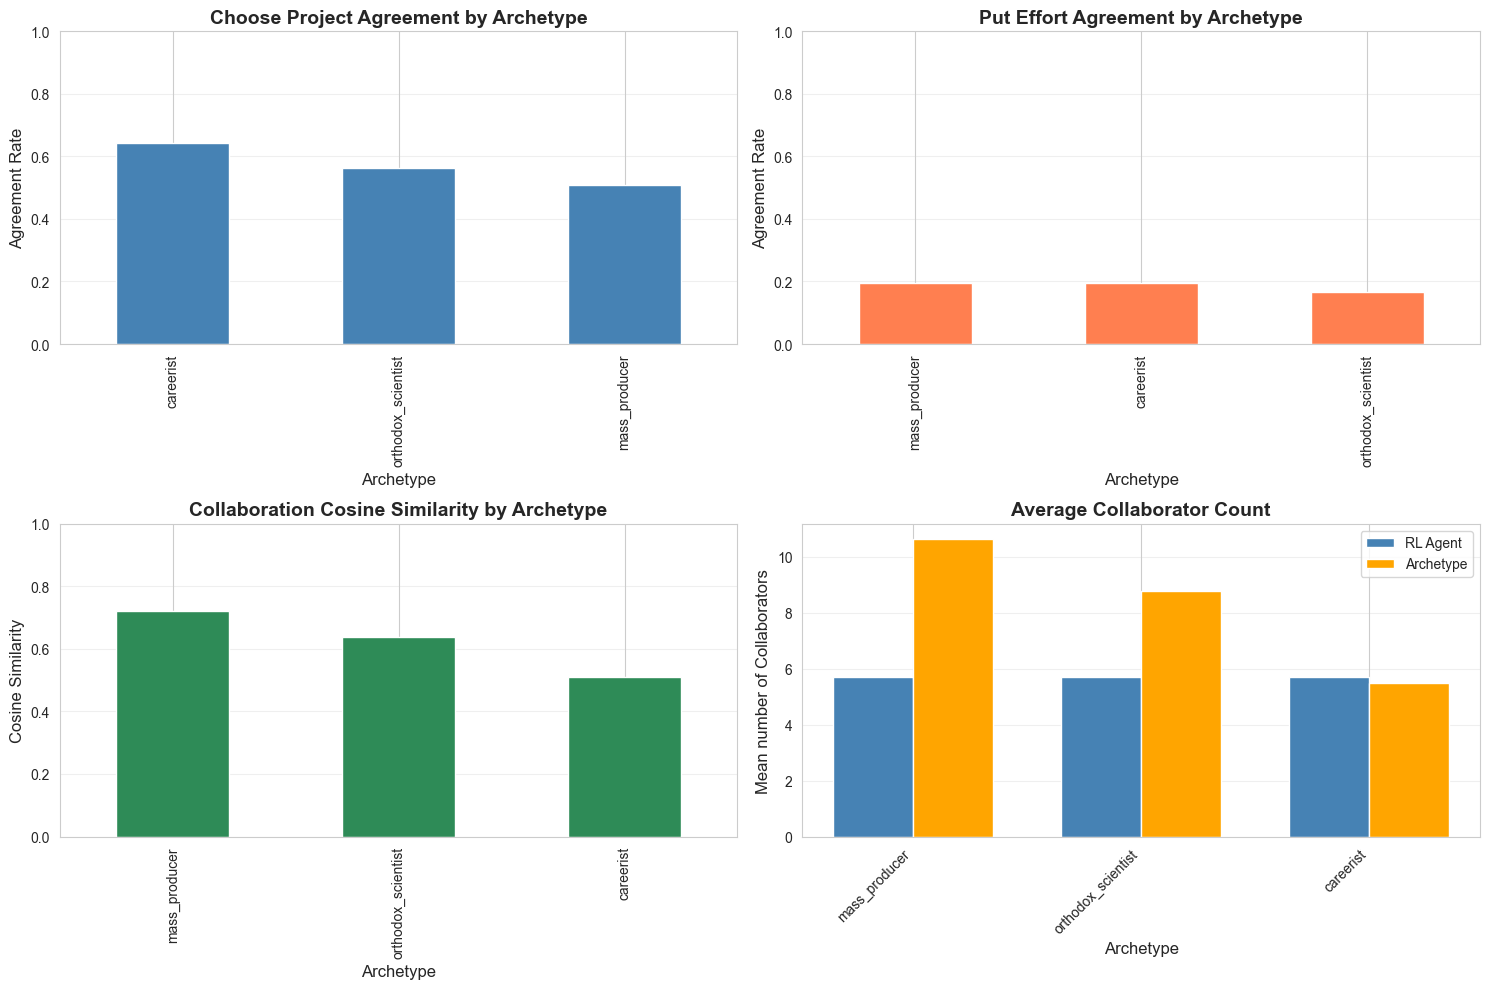

Saved plot to analysis_results\archetype_similarity\similarity_by_archetype.png


In [40]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Choose project agreement
ax = axes[0, 0]
summary_by_archetype.sort_values("choose_project_agreement", ascending=False).plot(
    x="archetype", y="choose_project_agreement", kind="bar", ax=ax, legend=False, color="steelblue"
)
ax.set_title("Choose Project Agreement by Archetype", fontsize=14, fontweight="bold")
ax.set_ylabel("Agreement Rate", fontsize=12)
ax.set_xlabel("Archetype", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Put effort agreement
ax = axes[0, 1]
summary_by_archetype.sort_values("put_effort_agreement", ascending=False).plot(
    x="archetype", y="put_effort_agreement", kind="bar", ax=ax, legend=False, color="coral"
)
ax.set_title("Put Effort Agreement by Archetype", fontsize=14, fontweight="bold")
ax.set_ylabel("Agreement Rate", fontsize=12)
ax.set_xlabel("Archetype", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Collaboration cosine similarity
ax = axes[1, 0]
summary_by_archetype.sort_values("collab_cosine_similarity", ascending=False).plot(
    x="archetype", y="collab_cosine_similarity", kind="bar", ax=ax, legend=False, color="seagreen"
)
ax.set_title("Collaboration Cosine Similarity by Archetype", fontsize=14, fontweight="bold")
ax.set_ylabel("Cosine Similarity", fontsize=12)
ax.set_xlabel("Archetype", fontsize=12)
ax.set_ylim(0, 1)
ax.grid(axis="y", alpha=0.3)

# Collaborator count comparison
ax = axes[1, 1]
x_pos = np.arange(len(summary_by_archetype))
width = 0.35
ax.bar(x_pos - width/2, summary_by_archetype["rl_collab_count"], width, label="RL Agent", color="steelblue")
ax.bar(x_pos + width/2, summary_by_archetype["archetype_collab_count"], width, label="Archetype", color="orange")
ax.set_title("Average Collaborator Count", fontsize=14, fontweight="bold")
ax.set_ylabel("Mean number of Collaborators", fontsize=12)
ax.set_xlabel("Archetype", fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(summary_by_archetype["archetype"], rotation=45, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "similarity_by_archetype.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to {OUTPUT_DIR / 'similarity_by_archetype.png'}")

### Line Plot: Similarity Over Time

In [41]:
if summary_by_time is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for i, (metric, title) in enumerate([
        ("choose_project_agreement", "Choose Project Agreement"),
        ("put_effort_agreement", "Put Effort Agreement"),
        ("collab_cosine_similarity", "Collaboration Cosine Similarity"),
    ]):
        ax = axes[i]
        
        for archetype in summary_by_time["archetype"].unique():
            data = summary_by_time[summary_by_time["archetype"] == archetype]
            ax.plot(data["step_mid"], data[metric], marker="o", label=archetype, linewidth=2)
        
        ax.set_title(title, fontsize=13, fontweight="bold")
        ax.set_xlabel("Timestep", fontsize=11)
        ax.set_ylabel("Similarity", fontsize=11)
        ax.set_ylim(0, 1)
        ax.legend()
        ax.grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "similarity_over_time.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"Saved plot to {OUTPUT_DIR / 'similarity_over_time.png'}")
else:
    print("Skipping time-based plots (no step column)")

NameError: name 'summary_by_time' is not defined

### Histogram: Collaborator Count Distribution

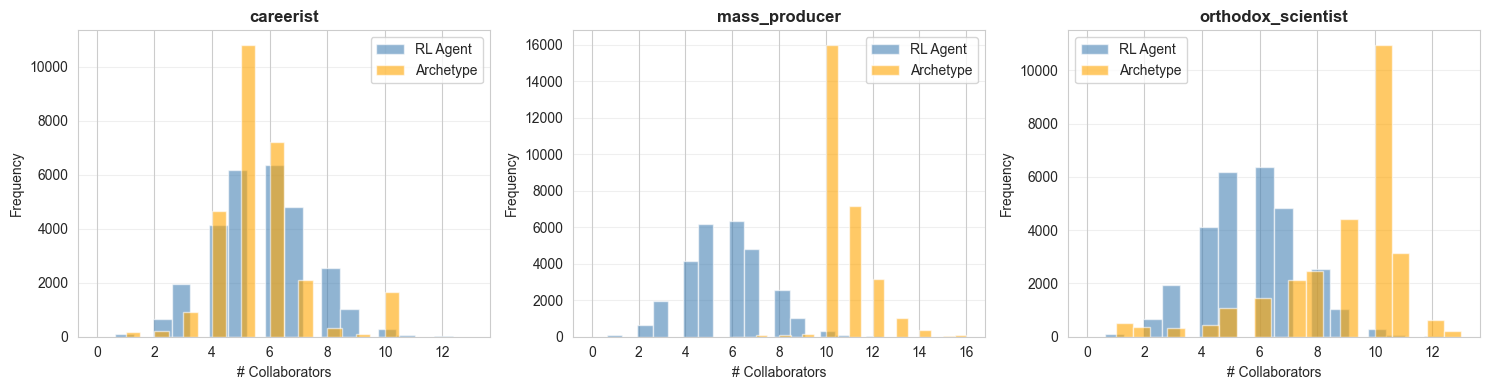

Saved plot to analysis_results\archetype_similarity\collaborator_count_distribution.png


In [42]:
fig, axes = plt.subplots(1, len(ARCHETYPE_POLICIES), figsize=(15, 4))

if len(ARCHETYPE_POLICIES) == 1:
    axes = [axes]

for i, archetype in enumerate(sorted(ARCHETYPE_POLICIES.keys())):
    ax = axes[i]
    data = df_similarity[df_similarity["archetype"] == archetype]
    
    ax.hist(data["rl_collab_count"], bins=20, alpha=0.6, label="RL Agent", color="steelblue")
    ax.hist(data["archetype_collab_count"], bins=20, alpha=0.6, label="Archetype", color="orange")
    
    ax.set_title(f"{archetype}", fontsize=12, fontweight="bold")
    ax.set_xlabel("# Collaborators", fontsize=10)
    ax.set_ylabel("Frequency", fontsize=10)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "collaborator_count_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved plot to {OUTPUT_DIR / 'collaborator_count_distribution.png'}")

## Save Outputs

In [ ]:
print("Saving outputs...")

# Save counterfactual actions
output_path = OUTPUT_DIR / "counterfactual_actions.parquet"
# Convert numpy arrays to lists for parquet serialization
df_save = df_counterfactual.copy()
df_save["rl_collaborate_with"] = df_save["rl_collaborate_with"].apply(lambda x: x.tolist())
df_save["archetype_collaborate_with"] = df_save["archetype_collaborate_with"].apply(lambda x: x.tolist())
df_save.to_parquet(output_path, index=False)
print(f"Saved: {output_path}")

# Save similarity metrics
output_path = OUTPUT_DIR / "similarity_metrics.parquet"
df_save.to_parquet(output_path, index=False)
print(f"Saved: {output_path}")

# Save summary tables
output_path = OUTPUT_DIR / "summary_by_archetype.csv"
summary_by_archetype.to_csv(output_path, index=False)
print(f"Saved: {output_path}")

if summary_by_seed_archetype is not None:
    output_path = OUTPUT_DIR / "summary_by_seed_archetype.csv"
    summary_by_seed_archetype.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

if summary_by_time is not None:
    output_path = OUTPUT_DIR / "summary_by_time.csv"
    summary_by_time.to_csv(output_path, index=False)
    print(f"Saved: {output_path}")

print(f"\nAll outputs saved to: {OUTPUT_DIR}")

## Interpretation Guide

### How to Read These Results

#### High Similarity to an Archetype

**What it means:**
- The RL agent's actions closely match what that archetype would have done on the states the RL agent actually visited
- The RL policy may have converged to a strategy similar to that archetype

**What it does NOT mean:**
- The RL agent will achieve the same performance as the archetype
- The archetype is optimal
- The RL agent has the same internal decision-making process

#### Low Similarity to All Archetypes

**Possible interpretations:**
1. **Novel strategy**: The RL agent learned a genuinely different approach
2. **Noisy behavior**: The policy is still exploring or unstable
3. **Action mask effects**: Invalid actions were repaired, changing the action distribution
4. **State distribution mismatch**: The RL agent visits states where archetype behavior is undefined or very different
5. **Insufficient observation features**: Archetypes may use additional heuristics not captured in observations

### Complementary Analyses

To fully understand the RL agent's behavior, combine this analysis with:

1. **Performance metrics**: Rewards, citations, publications, career advancement
2. **Action distributions**: What actions does the RL agent prefer overall?
3. **Project outcome analysis**: Which projects does the RL agent select and complete?
4. **Temporal patterns**: How does behavior change over episode time?
5. **State distribution analysis**: Which states does the RL agent visit most?
6. **Sensitivity analysis**: How do small observation changes affect actions?

### Key Metrics Explained

- **Choose Project Agreement**: % of times RL agent selects same project as archetype
- **Put Effort Agreement**: % of times RL agent allocates same effort level as archetype
- **Collaboration Cosine Similarity**: Vector similarity of collaboration choices (0=opposite, 1=identical)
- **Collaboration Exact Match**: % of times collaboration vectors are exactly identical
- **Hamming/Jaccard Similarity**: Alternative collaboration similarity metrics

### Caveats

⚠️ **State Distribution Dependency**
- Archetypes are evaluated on the RL agent's visited states only
- If an archetype ran its own rollout, it would visit different states
- Therefore, this measures behavioral similarity, NOT policy performance

⚠️ **Action Masking Effects**
- If invalid actions are masked or repaired, this affects the comparison
- An archetype might choose an invalid action that gets corrected to match the RL action

⚠️ **Observation Completeness**
- Archetypes may use heuristics or domain knowledge not captured in the observation space
- Missing features could artificially inflate or deflate similarity

### Recommended Next Steps

1. Examine specific timesteps where similarity is very high or very low
2. Analyze the state features at those timesteps
3. Compare performance metrics between RL agent and archetypes (from separate rollouts)
4. Investigate action mask usage and repair frequency
5. Visualize action distributions independently for RL and each archetype
6. Conduct sensitivity analysis on key observation features